In [15]:
# AUTOMATIC CROPPING OF IMAGES WITH BLACK BORDERS
# TR: Siyah Kenarlı Görüntülerde Otomatik Kırpma

In [16]:


# Bu konu, arka planı siyah olan görüntülerde nesneleri otomatik olarak tespit edip
# gereksiz siyah kenarları kırpma işlemini kapsar. Amaç, verilen bir görüntüdeki 
# nesneyi belirlemek ve yalnızca nesneyi içerecek şekilde görüntüyü kırpmaktır.

# İşlemler genellikle şu adımları içerir:
# 1. Griye Çevirme ve Maskeleme
#    - Renkli görüntü gri tonlamaya çevrilir.
#    - Siyah olmayan pikseller maske ile seçilir.
# 2. Morfolojik İşlemler
#    - Küçük boşlukları doldurmak ve kenarları düzgünleştirmek için 
#      morphologyEx(MORPH_CLOSE) uygulanır.
# 3. Kontur Tespiti
#    - Nesnenin konturları bulunur ve en büyük kontur seçilir.
# 4. Kırpma
#    - Kontur çevresine dikdörtgen oluşturulur ve görüntü bu alan temel alınarak kırpılır.
#    - İsteğe bağlı padding eklenebilir.
# 5. Sonuçların Gösterimi
#    - Kırpılmış görüntü OpenCV penceresinde gösterilir.

# Kullanım Alanları:
# - Görüntü ön işleme ve veri temizleme
# - Nesne tespiti sonrası veri optimizasyonu
# - Bilgisayarla görme (Computer Vision) projeleri
# - Fotoğraf ve doküman tarama uygulamaları


In [17]:
import cv2  # OpenCV kütüphanesini içe aktarır. 
#Görüntü okuma, yazma, filtreleme, yüz tanıma gibi işlemler için kullanılır.

import numpy as np  # NumPy kütüphanesini "np" kısaltmasıyla içe aktarır. 
# Diziler (array) oluşturmak ve matematiksel işlemler yapmak için kullanılır.


In [18]:
def cropped_black_borders(img: np.ndarray, thr=12, pad=0):
    
    # thr parametresi thresh değerini temsil eder. 
    # Arka planı siyah olan görüntülerdeki nesneyi ayırt etmek için siyah rengine yakın bir değer verir.

    # pad parametresi de padding e karşılık gelir. 
    # 

    if img.ndim == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img.copy()

    # Görüntüdeki siyah olmayan pikselleri seçer.
    mask = (gray > thr).astype(np.uint8) * 255 
    kernel = np.ones((5,5), dtype=np.uint8)

    thresh = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    # mask görüntüsüne morfolojik "close" işlemi uygular ve sonucu thresh değişkenine atar.
    # MORPH_CLOSE = önce genişletme (dilation) sonra aşındırma (erosion) uygular.
    # Amaç: küçük siyah delikleri kapatmak ve nesnenin kenarlarını düzgünleştirmek.
    # kernel = işlemin uygulanacağı 5x5 boyutunda bir matris (structuring element)
    # iterations=2 → işlemi iki kez tekrarlar, böylece etkisi artar


    # Kenar tespiti için eşikleme işleminden sonra kontur bulma işlemi yapılır.
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Seçilen kontur listesindeki en büyük konturu seç
    c = max(contours, key=cv2.contourArea)

    # Seçilen konturu da bir dikdörtgen haline getir.
    x, y, w, h = cv2.boundingRect(c)

    # Kontura göre seçilen elemanın (arka plandan ayırt edilmek istenen değişkenin) 
    # orijinal görüntü boyutlarından taşmaması için önlem alınır.

    # Önce yüksekliği ve genişliği , görüntünün kendisinden alınır.
    H, W = img.shape[:2]

    x1 = max(0, x - pad)  # sol taraftan taşma olmamasını sağlar
    y1 = max(0, y - pad)  # üst taraftan taşma olmamasını sağlar
    x2 = min(W, x + w + pad)  # sağ taraftan taşma olmamasını sağlar
    y2 = min(H, y + h + pad)  # alt taraftan taşma olmamasını sağlar

    # Kırpılmış görüntüyü döndür
    return img[y1:y2, x1:x2]


In [19]:
# Yukarıda fonksiyon tanımlandı. 
# AŞAĞIDA istenilen görüntüyle çalıştır.

my_bgr_img = cv2.imread("./Hafta_7/yeni1.png")
# "./Hafta_7/yeni1.png" yolundaki resmi BGR formatında okur ve my_bgr_img değişkenine atar.

cropped_img = cropped_black_borders(my_bgr_img, 10, 0)
# Daha önce tanımlanan cropped_black_borders fonksiyonunu çağırır.
# my_bgr_img görüntüsündeki siyah kenarları kırpar.
# thr=10 → siyah piksellerin eşik değeri
# pad=0 → kırpma sırasında kenarlara ek padding uygulanmaz
# Fonksiyon kırpılmış görüntüyü cropped_img değişkenine atar.

cv2.imshow("CROPPED İMAGE", my_bgr_img)
# Orijinal görüntüyü ekranda gösterir.
# Pencere başlığı olarak "CROPPED İMAGE" kullanılır.

cv2.waitKey(0)
# Kullanıcı herhangi bir tuşa basana kadar pencereyi açık tutar.

cv2.destroyAllWindows()
# Açık olan tüm OpenCV pencerelerini kapatır


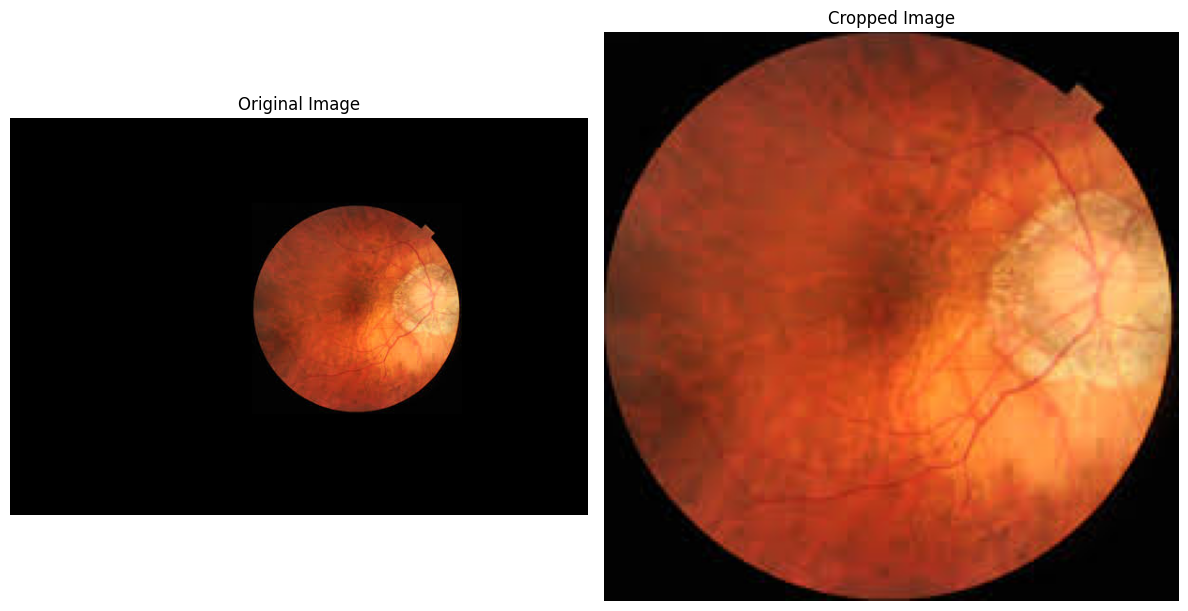

In [23]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Fonksiyon: Siyah kenarları kırp
def cropped_black_borders(img: np.ndarray, thr=12, pad=0):
    if img.ndim == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img.copy()

    mask = (gray > thr).astype(np.uint8) * 255 
    kernel = np.ones((5,5), dtype=np.uint8)
    thresh = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    c = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)

    H, W = img.shape[:2]
    x1 = max(0, x - pad)
    y1 = max(0, y - pad)
    x2 = min(W, x + w + pad)
    y2 = min(H, y + h + pad)

    return img[y1:y2, x1:x2]

# Görüntüyü oku
my_bgr_img = cv2.imread("./Hafta_7/yeni1.png")

# Kopya üzerinde kırpma işlemi uygula
cropped_img = cropped_black_borders(my_bgr_img.copy(), thr=10, pad=0)

# Yan yana gösterim
plt.figure(figsize=(12,6))

# 1. subplot → Orijinal görüntü
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(my_bgr_img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

# 2. subplot → Kırpılmış görüntü
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB))
plt.title("Cropped Image")
plt.axis('off')

plt.tight_layout()
plt.show()


In [20]:
# Yukarıda fonksiyon tanımlandı. 
# AŞAĞIDA istenilen görüntüyle çalıştır.

my_bgr_img = cv2.imread("./Hafta_7/bonus.jpg")

cropped_img = cropped_black_borders(my_bgr_img, 10, 0)

cv2.imshow("CROPPED İMAGE", my_bgr_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [21]:
# ÖZET:

# - Bu konu, arka planı siyah olan görüntülerde nesneleri otomatik olarak tespit edip
#   gereksiz siyah kenarları kırpma işlemini kapsar.
# - Görüntü hem renkli (BGR) hem de gri tonlamalı olarak işlenebilir.
#   Kırpma işlemleri genellikle gri tonlamalı görüntü üzerinde maske oluşturularak yapılır.
# - Siyah olmayan pikseller tespit edilerek nesnenin bulunduğu alan maske ile belirlenir.
# - cv2.morphologyEx() fonksiyonu ile küçük boşluklar doldurulur ve kenarlar düzgünleştirilir.
# - cv2.findContours() ile nesnenin konturları bulunur ve en büyük kontur seçilir.
# - cv2.boundingRect() ile nesne çevresine dikdörtgen hesaplanır.
#   - padding eklenebilir veya sıfır bırakılabilir.
# - Görüntü, kontur dikdörtgeni temel alınarak kırpılır ve cv2.imshow() ile ekranda gösterilir.
#   cv2.waitKey(0) → tuş basılana kadar pencere açık kalır.
#   cv2.destroyAllWindows() → tüm pencereler kapatılır.
# - Bu konu, bilgisayarla görme (Computer Vision) alanında
#   görüntü ön işleme, nesne tespiti ve veri optimizasyonu için temel bir uygulamadır.
# - Kullanım alanları:
#   - Görüntü ön işleme ve veri temizleme
#   - Nesne tespiti sonrası veri optimizasyonu
#   - Bilgisayarla görme projeleri
#   - Fotoğraf ve doküman tarama uygulamaları
